# Logistic Regression — Basics

A practical introduction to **Logistic Regression** for binary classification.

## Topics Covered

- Binary Classification
- Logistic Regression
- Sigmoid Function
- Probability Prediction
- Decision Threshold
- Train-Test Split
- Model Training
- Class Prediction
- Classification Report
- Confusion Matrix
- ROC Curve
- ROC-AUC Score
- Decision Boundary

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [2]:
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (500, 2)
Target Shape: (500,)


In [3]:
df = pd.DataFrame(
    X,
    columns=["Feature_1", "Feature_2"]
)

df["Target"] = y

df.head()

,Feature_1,Feature_2,Target
0,1.508455,-1.547010,0
1,0.826021,1.002541,1
2,1.524205,-2.297143,0
3,0.621880,0.559371,0
4,0.539100,0.882369,1


In [4]:
print("Class Distribution:")
print(df["Target"].value_counts())

Class Distribution:
Target
1    251
0    249
Name: count, dtype: int64


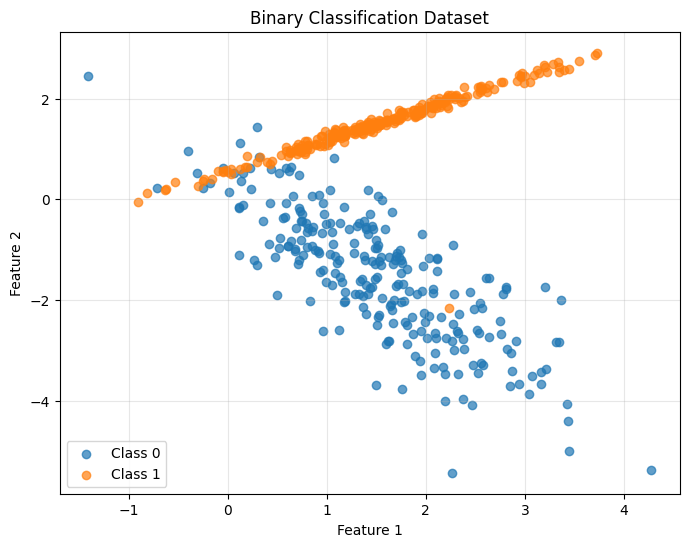

In [5]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df[df["Target"] == 0]["Feature_1"],
    df[df["Target"] == 0]["Feature_2"],
    label="Class 0",
    alpha=0.7
)

plt.scatter(
    df[df["Target"] == 1]["Feature_1"],
    df[df["Target"] == 1]["Feature_2"],
    label="Class 1",
    alpha=0.7
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 400
Testing Samples: 100


In [7]:
model = LogisticRegression(
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [8]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: [-1.16812193]
Coefficients: [[0.20577941 2.83679172]]


In [9]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Predictions:
[1 0 0 1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 1 0]


In [10]:
y_prob = model.predict_proba(X_test)

print("First 10 Probability Predictions:")
print(y_prob[:10])

First 10 Probability Predictions:
[[7.35949946e-02 9.26405005e-01]
 [9.99961685e-01 3.83153478e-05]
 [9.99873669e-01 1.26330731e-04]
 [9.30416506e-02 9.06958349e-01]
 [1.14367455e-02 9.88563255e-01]
 [2.38769837e-03 9.97612302e-01]
 [6.21448016e-02 9.37855198e-01]
 [4.41858379e-01 5.58141621e-01]
 [9.99751658e-01 2.48342406e-04]
 [9.95812817e-01 4.18718258e-03]]


In [11]:
class_1_probability = y_prob[:, 1]

print(class_1_probability[:10])

[9.26405005e-01 3.83153478e-05 1.26330731e-04 9.06958349e-01
 9.88563255e-01 9.97612302e-01 9.37855198e-01 5.58141621e-01
 2.48342406e-04 4.18718258e-03]


In [12]:
threshold = 0.50

y_pred_threshold = (class_1_probability >= threshold).astype(int)

print("Threshold:", threshold)
print("Predictions:", y_pred_threshold[:20])

Threshold: 0.5
Predictions: [1 0 0 1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 1 0]


In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.97
Precision: 0.9433962264150944
Recall   : 1.0
F1-Score : 0.970873786407767


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        50
           1       0.94      1.00      0.97        50

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



In [15]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[47  3]
 [ 0 50]]


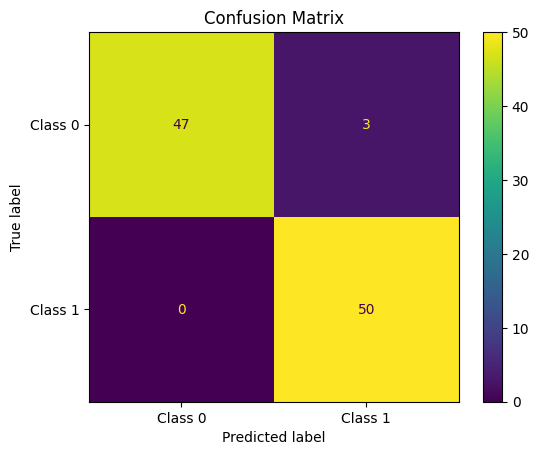

In [16]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [17]:
roc_auc = roc_auc_score(
    y_test,
    class_1_probability
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9984


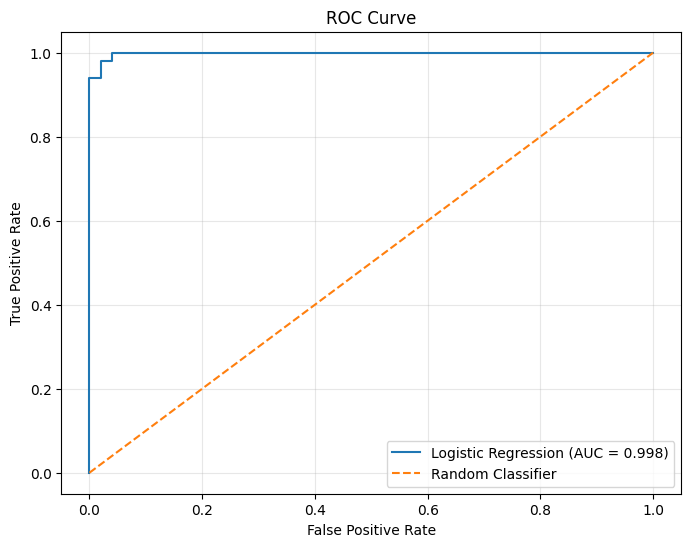

In [18]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    class_1_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [19]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

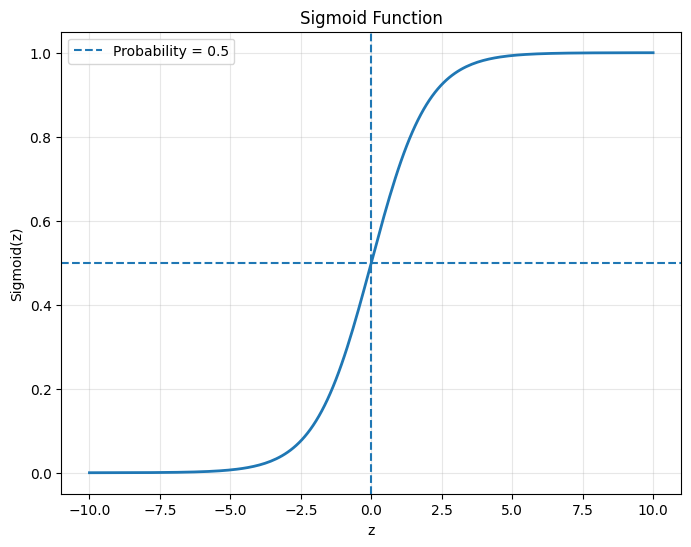

In [20]:
z = np.linspace(-10, 10, 200)

probabilities = sigmoid(z)

plt.figure(figsize=(8, 6))

plt.plot(
    z,
    probabilities,
    linewidth=2
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Probability = 0.5"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.title("Sigmoid Function")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [21]:
x_min = X[:, 0].min() - 1
x_max = X[:, 0].max() + 1

y_min = X[:, 1].min() - 1
y_max = X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = model.predict(grid)

Z = Z.reshape(xx.shape)

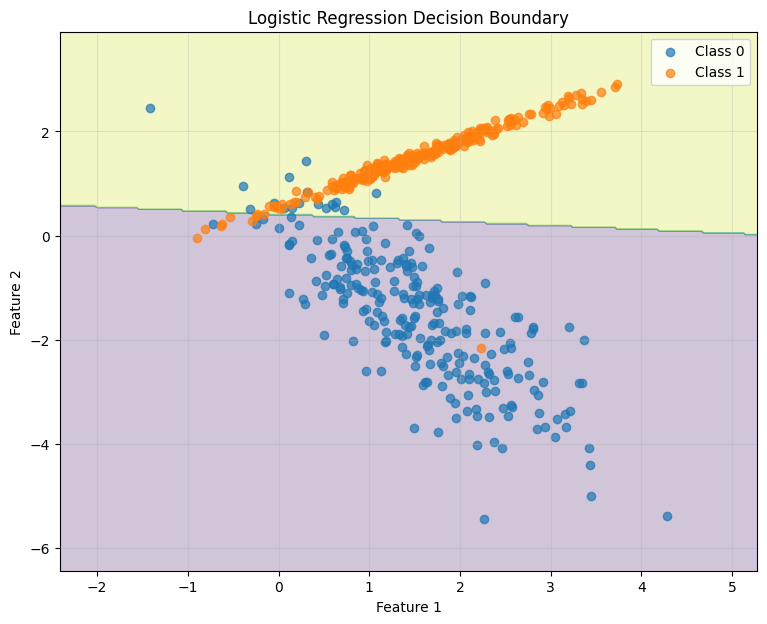

In [22]:
plt.figure(figsize=(9, 7))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.25
)

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0",
    alpha=0.7
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1",
    alpha=0.7
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [23]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results

,Metric,Score
0,Accuracy,0.970000
1,Precision,0.943396
2,Recall,1.000000
3,F1-Score,0.970874
4,ROC-AUC,0.998400


## Key Takeaways

- **Logistic Regression** is primarily used for binary classification.
- The model first calculates a linear combination of the input features.
- The **Sigmoid Function** converts this value into a probability between 0 and 1.
- A **decision threshold** converts the probability into a class prediction.
- `predict()` returns the predicted class.
- `predict_proba()` returns class probabilities.
- **Precision, Recall, and F1-Score** provide detailed classification performance.
- The **Confusion Matrix** shows TP, TN, FP, and FN.
- The **ROC Curve** evaluates the model across different thresholds.
- **ROC-AUC** measures the model's ability to distinguish between classes.
- The **Decision Boundary** shows how Logistic Regression separates the two classes.